# In-Context BIM Scene Rendering

Renders a BIM object within its scene context: the target object is highlighted in color,
while neighboring objects from the same IFC source file are shown in semi-transparent gray.
All OBJ meshes are in world-space coordinates, so objects from the same source align automatically.

In [1]:
%pip install pyrender trimesh
import trimesh
import pyrender
import numpy as np
import json
import os
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline

DATA_DIR = Path('../../data')
MESH_DIR = Path('../../processed_data/meshes/train')

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Load annotated metadata and group by IFC source file
with open(DATA_DIR / 'annotated_metadata.json') as f:
    annotated_meta = json.load(f)

# Build {relative_source_path: [entries]} dict
source_groups = {}
for m in annotated_meta:
    src = m['relative_source_path']
    source_groups.setdefault(src, []).append(m)

meta_by_gid = {m['GlobalId']: m for m in annotated_meta}

print(f"Total objects: {len(annotated_meta)}")
print(f"IFC sources: {len(source_groups)}")

# Pick a target object that has a mesh file and neighbors
chosen = None
for src, entries in source_groups.items():
    existing = [e for e in entries if (MESH_DIR / e['mesh_filename']).exists()]
    if len(existing) >= 5:
        chosen = existing[3 % len(existing)]  # pick one deterministically
        break

print(f"\nTarget: {chosen['GlobalId']}")
print(f"IFC Type: {chosen['IfcType']}")
print(f"Source: {chosen['relative_source_path']}")
print(f"Objects from same source: {len(source_groups[chosen['relative_source_path']])}")

Total objects: 1889
IFC sources: 158

Target: 20cJihxHXtI8kTGu067gQn
IFC Type: IfcStair
Source: BIM.fundamental 950799697 (S25)-Submission Assignment 1-3415395/Maylis Clavery_11921023_assignsubmission_file/1.assignment_BIM_03800428.ifc
Objects from same source: 24


In [3]:
def build_scene(target_gid, source_groups, meta_by_gid, mesh_dir,
                radius_mult=3.0, target_color=(0.2, 0.4, 0.8, 1.0),
                context_color=(0.6, 0.6, 0.6, 0.3)):
    """Build a pyrender scene with the target object highlighted and neighbors in context.

    Args:
        target_gid: GlobalId of the target object
        source_groups: dict mapping source path to list of metadata entries
        meta_by_gid: dict mapping GlobalId to metadata
        mesh_dir: Path to mesh directory
        radius_mult: multiplier on target bounding radius to find neighbors
        target_color: RGBA color for the target object
        context_color: RGBA color for context objects

    Returns:
        (scene, target_centroid, camera_distance)
    """
    target_meta = meta_by_gid[target_gid]
    target_path = mesh_dir / target_meta['mesh_filename']
    target_mesh = trimesh.load(str(target_path), force='mesh')

    target_centroid = target_mesh.centroid
    target_radius = target_mesh.bounding_sphere.primitive.radius
    neighbor_radius = radius_mult * target_radius

    # Create pyrender scene with ambient light
    scene = pyrender.Scene(ambient_light=[0.3, 0.3, 0.3], bg_color=[1.0, 1.0, 1.0, 1.0])

    # Add directional light
    light = pyrender.DirectionalLight(color=[1.0, 1.0, 1.0], intensity=3.0)
    scene.add(light, pose=np.eye(4))

    # Add target mesh (highlighted)
    target_material = pyrender.MetallicRoughnessMaterial(
        baseColorFactor=target_color,
        metallicFactor=0.1,
        roughnessFactor=0.7,
    )
    target_pr = pyrender.Mesh.from_trimesh(target_mesh, material=target_material)
    scene.add(target_pr)

    # Load neighbors from the same IFC source
    source_path = target_meta['relative_source_path']
    siblings = source_groups.get(source_path, [])

    context_material = pyrender.MetallicRoughnessMaterial(
        baseColorFactor=context_color,
        metallicFactor=0.0,
        roughnessFactor=0.9,
        alphaMode='BLEND',
    )

    n_loaded = 0
    for entry in siblings:
        if entry['GlobalId'] == target_gid:
            continue
        obj_path = mesh_dir / entry['mesh_filename']
        if not obj_path.exists():
            continue
        try:
            mesh = trimesh.load(str(obj_path), force='mesh')
        except Exception:
            continue

        dist = np.linalg.norm(mesh.centroid - target_centroid)
        if dist <= neighbor_radius:
            pr_mesh = pyrender.Mesh.from_trimesh(mesh, material=context_material)
            scene.add(pr_mesh)
            n_loaded += 1

    print(f"Scene: 1 target + {n_loaded} context objects (radius={neighbor_radius:.2f}m)")

    camera_distance = max(target_radius * 4.0, 2.0)
    return scene, target_centroid, camera_distance

In [4]:
def render_views(scene, centroid, distance, width=800, height=600):
    """Render 9 views orbiting around the target centroid.

    Views: front, right, back, left, top, bottom, front-right, back-left, isometric.
    """
    camera = pyrender.PerspectiveCamera(yfov=np.pi / 3.0)

    # 9 camera angles: (azimuth_deg, elevation_deg)
    view_angles = [
        (0, 0),      # front
        (90, 0),     # right
        (180, 0),    # back
        (270, 0),    # left
        (0, 90),     # top
        (0, -90),    # bottom
        (45, 30),    # front-right
        (225, 30),   # back-left
        (35, 25),    # isometric
    ]

    def camera_pose(azimuth_deg, elevation_deg):
        az = np.radians(azimuth_deg)
        el = np.radians(elevation_deg)
        # Camera position on sphere around centroid
        x = distance * np.cos(el) * np.sin(az)
        y = distance * np.sin(el)
        z = distance * np.cos(el) * np.cos(az)
        eye = centroid + np.array([x, y, z])

        # Look-at matrix
        forward = centroid - eye
        forward /= np.linalg.norm(forward)
        world_up = np.array([0.0, 1.0, 0.0])
        if abs(np.dot(forward, world_up)) > 0.99:
            world_up = np.array([0.0, 0.0, 1.0])
        right = np.cross(forward, world_up)
        right /= np.linalg.norm(right)
        up = np.cross(right, forward)

        pose = np.eye(4)
        pose[:3, 0] = right
        pose[:3, 1] = up
        pose[:3, 2] = -forward
        pose[:3, 3] = eye
        return pose

    renderer = pyrender.OffscreenRenderer(width, height)
    images = []

    cam_node = scene.add(camera)

    for az, el in view_angles:
        pose = camera_pose(az, el)
        scene.set_pose(cam_node, pose)
        color, _ = renderer.render(scene)
        images.append(color)

    renderer.delete()
    scene.remove_node(cam_node)

    return images

# Build scene and render
scene, centroid, cam_dist = build_scene(
    chosen['GlobalId'], source_groups, meta_by_gid, MESH_DIR
)
images = render_views(scene, centroid, cam_dist)
print(f"Rendered {len(images)} views at {images[0].shape[1]}x{images[0].shape[0]}")

Scene: 1 target + 5 context objects (radius=7.57m)
Rendered 9 views at 800x600


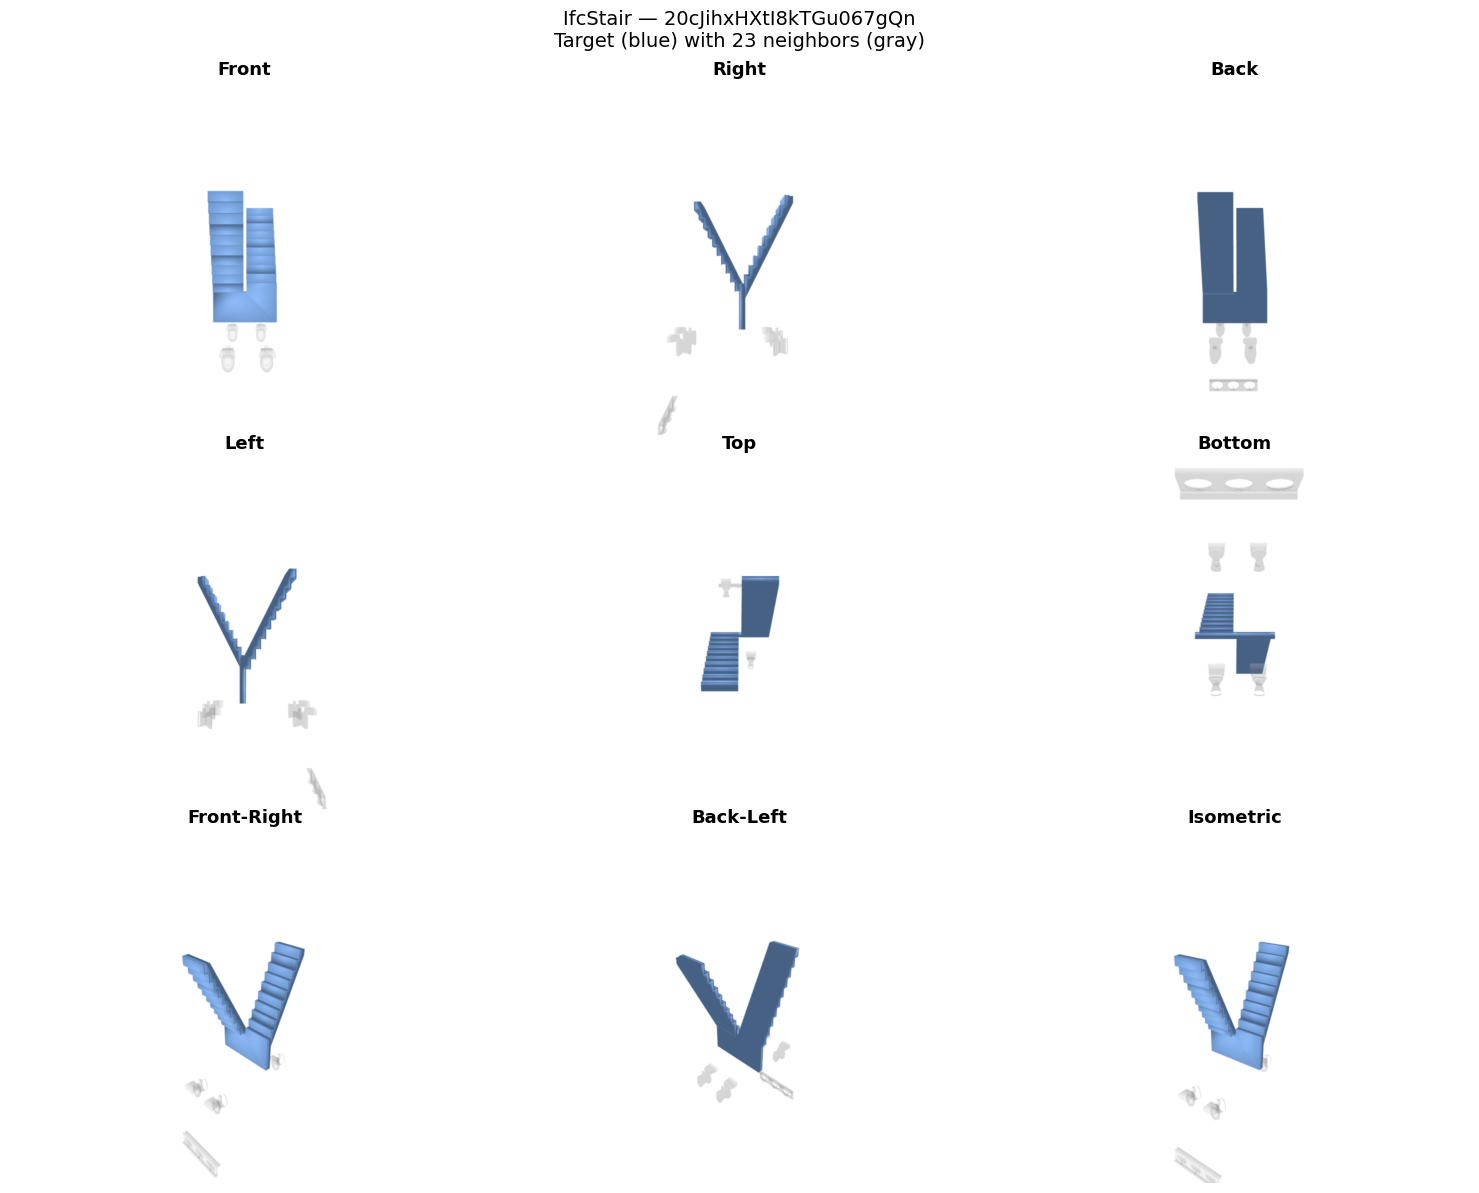

In [5]:
# Display 3x3 grid of rendered views
view_labels = ['Front', 'Right', 'Back', 'Left', 'Top', 'Bottom',
               'Front-Right', 'Back-Left', 'Isometric']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, (img, label) in enumerate(zip(images, view_labels)):
    axes[i].imshow(img)
    axes[i].set_title(label, fontsize=13, fontweight='bold')
    axes[i].axis('off')

fig.suptitle(
    f'{chosen["IfcType"]} — {chosen["GlobalId"]}\n'
    f'Target (blue) with {len(source_groups[chosen["relative_source_path"]])-1} neighbors (gray)',
    fontsize=14, y=0.99
)
plt.tight_layout()
plt.show()